In [114]:
import arviz.preview as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
from scipy import stats
from xarray import open_datatree

jax.config.update("jax_enable_x64", True)

In [115]:
NUM_OBS = [50, 250, 500, 1000]

## RDM

In [116]:
dt_dict_rdm_approx = {}

for t in NUM_OBS:
    dt_path = f"../multirun/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/test_num_obs={t}/train_steps=500000/parameter_recovery_approx.nc"
    dt_dict_rdm_approx[t] = open_datatree(dt_path)

In [117]:
dt_dict_rdm_ref = {}

for t in NUM_OBS:
    dt_path = f"../multirun/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/test_num_obs={t}/train_steps=500000/parameter_recovery_ref.nc"
    dt_dict_rdm_ref[t] = open_datatree(dt_path)

In [118]:
num_obs_coord = xr.DataArray(NUM_OBS, dims="num_obs")   

def merge_datatrees(dt_dict):
    groups = ["posterior", "constant_data", "prior"]                                                                                                                                            
                                                                                                                                                                                            
    dt_merged = xr.DataTree.from_dict({                                                                                                                                                            
        group: xr.concat(                                                                                                                                                                       
            [dt_dict[t][group].ds for t in NUM_OBS],                                                                                                                                            
            dim=num_obs_coord                                                                                                                                                                   
        )                                                                                                                                                                                       
        for group in groups                                                                                                                                                                     
    })

    dt_merged.attrs = dt_dict[50].attrs

    return dt_merged

In [119]:
dt_merged_rdm_approx = merge_datatrees(dt_dict_rdm_approx)
dt_merged_rdm_ref = merge_datatrees(dt_dict_rdm_ref)

In [120]:
def stack_posterior(dt):
    return (dt["posterior"].ds[dt.param_names]                                                                                                                  
    .to_array(dim="param")                                                                                       
    .to_dataset(name="theta")                                                                                                               
    ).merge(dt["constant_data"].ds.rename({"theta": "true"}))

In [121]:
posterior_stacked_rdm_approx = stack_posterior(dt_merged_rdm_approx)
posterior_stacked_rdm_ref = stack_posterior(dt_merged_rdm_ref)

In [122]:
def calc_posterior_median_df(posterior_stacked):
    return (posterior_stacked
        .median(dim=["chain", "draw"])
    ).to_dataframe().reset_index()

In [123]:
df_posterior_median_rdm_approx = calc_posterior_median_df(posterior_stacked_rdm_approx)
df_posterior_median_rdm_ref = calc_posterior_median_df(posterior_stacked_rdm_ref)

df_posterior_median_rdm_join = df_posterior_median_rdm_approx.merge(
    df_posterior_median_rdm_ref,
    on=["subject", "num_obs", "param"],
    suffixes=["_approx", "_ref"]
)


In [124]:
def calc_posterior_median_true_correlation(df):
    return (df
        .drop(["subject"], axis=1)
        .groupby(["num_obs", "param"])
        .corr()
        .iloc[0::2,-1]
        .reset_index()
    )

In [125]:
df_cor_rdm_approx = calc_posterior_median_true_correlation(df_posterior_median_rdm_approx)
df_cor_rdm_approx

,num_obs,param,level_2,true
0,50,b,theta,0.916112
1,50,s_true,theta,0.823659
2,50,t0,theta,0.947192
3,50,v_intercept,theta,0.380461
4,50,v_slope,theta,0.803185
5,250,b,theta,0.969486
6,250,s_true,theta,0.955957
7,250,t0,theta,0.985965
8,250,v_intercept,theta,0.762919
9,250,v_slope,theta,0.935510


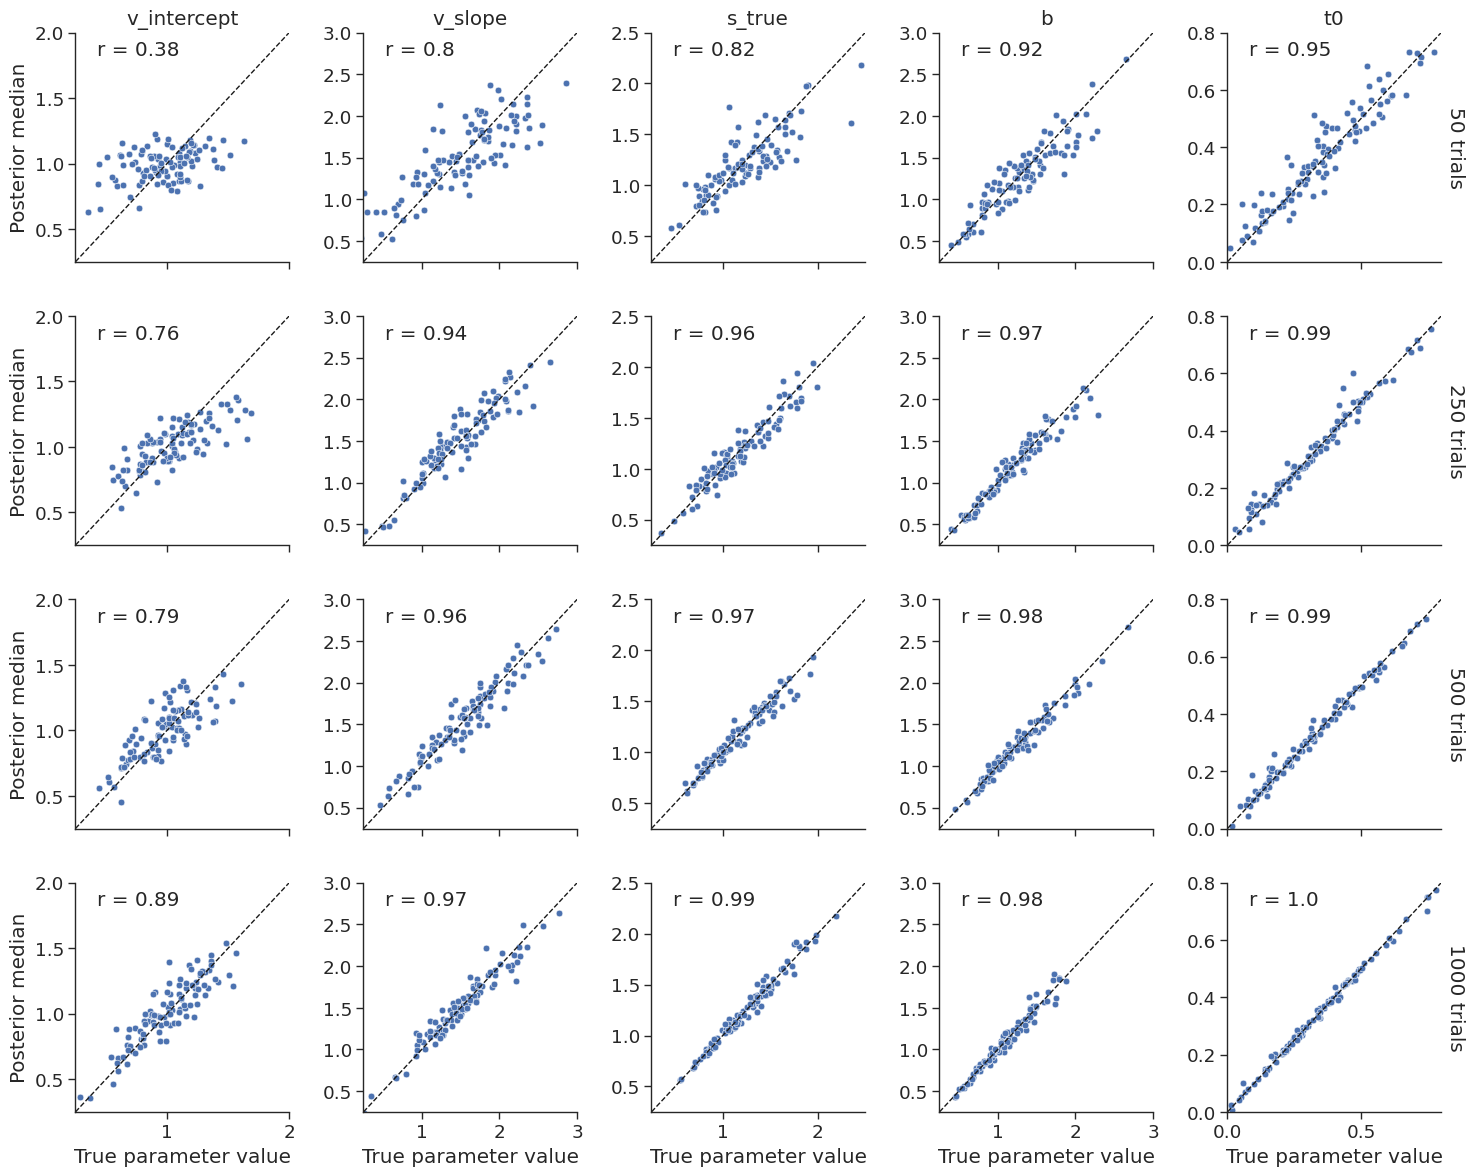

In [126]:
sns.set_theme(context="paper", style="ticks", font_scale=1.5)

g = sns.FacetGrid(df_posterior_median_rdm_approx, row="num_obs", col="param", sharex=False, sharey=False, margin_titles=True)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.scatterplot, x="true", y="theta")

g.set_xlabels(label="True parameter value")
g.set_ylabels(label="Posterior median")

g.set_titles(col_template="{col_name}", row_template="{row_name} trials")

lims_dict = {
    "v_intercept": (0.25, 2.0),
    "v_slope": (0.25, 3.0),
    "s_true": (0.25, 2.5),
    "b": (0.25, 3.0),
    "t0": (0, 0.8),
}

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val != 1000:
        ax.set_xticklabels([])

    ax.set_xlim(lims_dict[col_val])
    ax.set_ylim(lims_dict[col_val])
    ax.plot(lims_dict[col_val], lims_dict[col_val], 'k--', lw=1)
    cor = np.round(df_cor_rdm_approx[(df_cor_rdm_approx["num_obs"] == row_val) & (df_cor_rdm_approx["param"] == col_val)]["true"].item(), 2)
    ax.text(0.1, 0.9, f"r = {cor}", transform=ax.transAxes)

g.savefig("parameter_recovery/parameter_recovery_single_rdm.png")

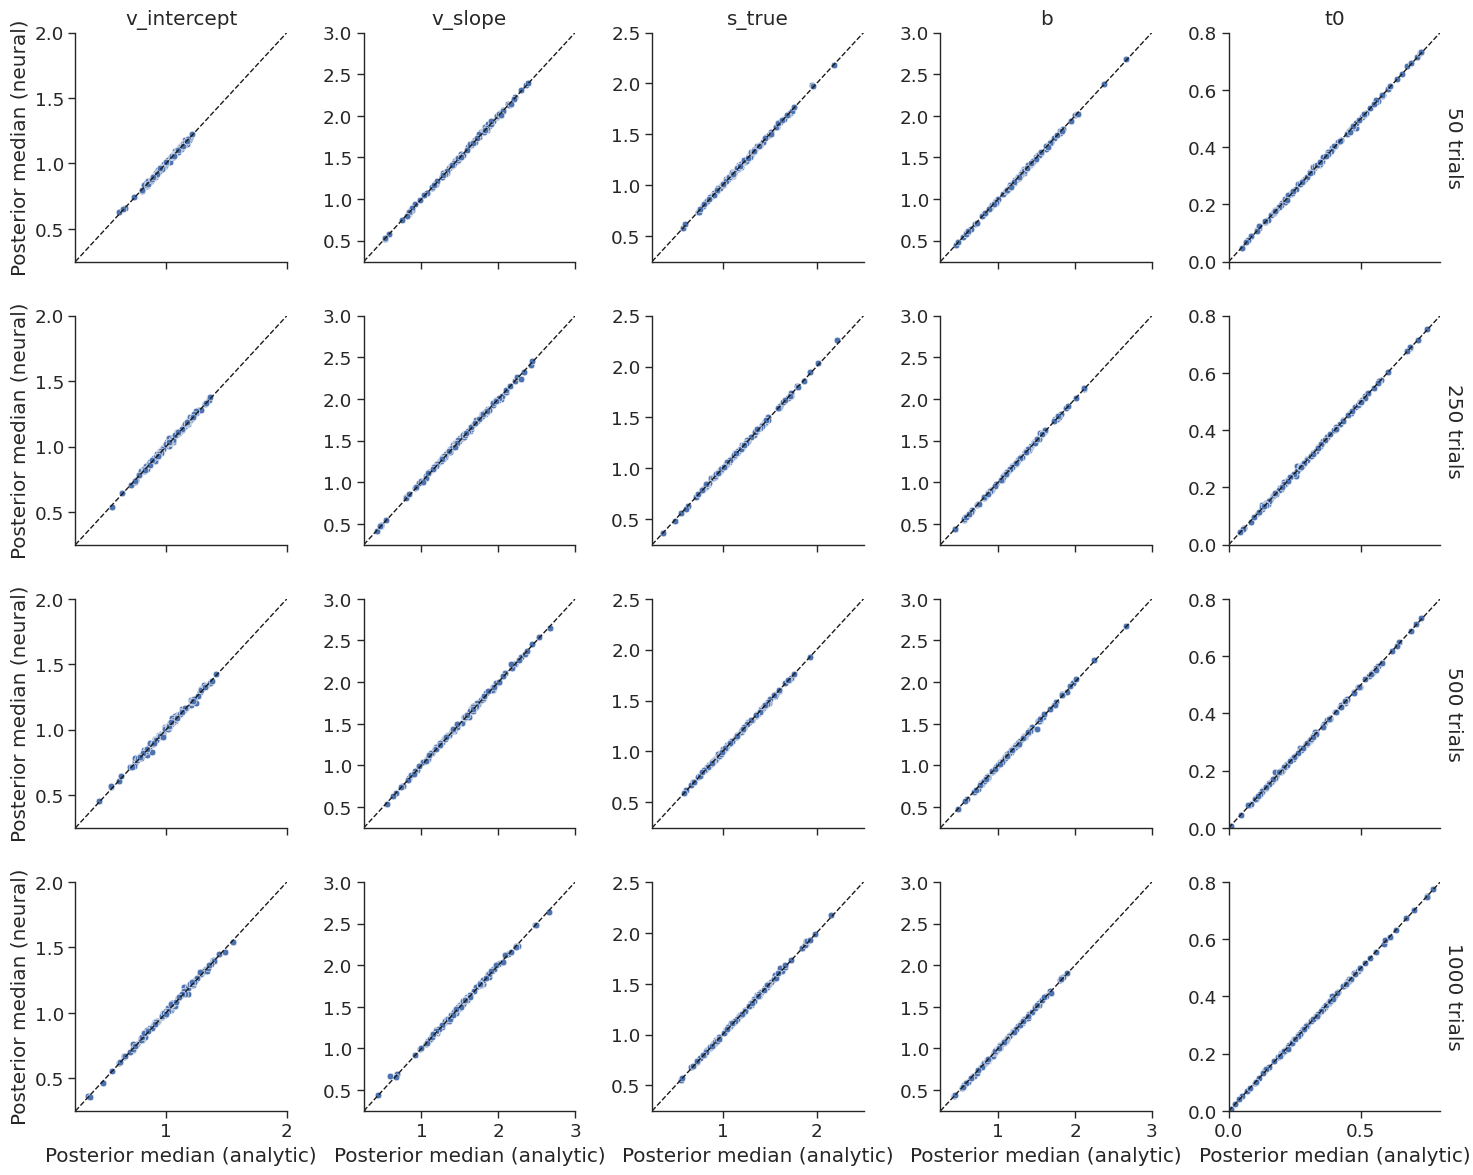

In [127]:
sns.set_theme(context="paper", style="ticks", font_scale=1.5)

g = sns.FacetGrid(df_posterior_median_rdm_join, row="num_obs", col="param", sharex=False, sharey=False, margin_titles=True)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.scatterplot, x="theta_ref", y="theta_approx")

g.set_xlabels(label="Posterior median (analytic)")
g.set_ylabels(label="Posterior median (neural)")

g.set_titles(col_template="{col_name}", row_template="{row_name} trials")

lims_dict = {
    "v_intercept": (0.25, 2.0),
    "v_slope": (0.25, 3.0),
    "s_true": (0.25, 2.5),
    "b": (0.25, 3.0),
    "t0": (0, 0.8),
}

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val != 1000:
        ax.set_xticklabels([])

    ax.set_xlim(lims_dict[col_val])
    ax.set_ylim(lims_dict[col_val])
    ax.plot(lims_dict[col_val], lims_dict[col_val], 'k--', lw=1)

g.savefig("parameter_recovery/parameter_cross_recovery_single_rdm.png")

In [128]:
def merge_prior(posterior_stacked, dt):
    return posterior_stacked.merge(dt["prior"].ds[dt.param_names].to_array(dim="param").to_dataset(name="prior"))

In [129]:
posterior_prior_stacked_rdm_approx = merge_prior(posterior_stacked_rdm_approx, dt_merged_rdm_approx)
posterior_prior_stacked_rdm_ref = merge_prior(posterior_stacked_rdm_ref, dt_merged_rdm_ref)

In [130]:
def calc_posterior_contraction_df(dt):
    posterior_var = dt.theta.var(dim=["chain", "draw"])
    prior_var = dt.prior.var(dim=["draw"])
    return ((1.0 - (posterior_var / prior_var))
        .to_dataset(name="contraction")
        .merge(dt.mean(dim=["chain", "draw"]))
        .to_dataframe()
        .reset_index()
    )

In [131]:
df_posterior_contraction_rdm_approx = calc_posterior_contraction_df(posterior_prior_stacked_rdm_approx)
df_posterior_contraction_rdm_ref = calc_posterior_contraction_df(posterior_prior_stacked_rdm_ref)

df_posterior_contraction_rdm_join = df_posterior_contraction_rdm_approx.merge(
    df_posterior_contraction_rdm_ref, on=["subject", "num_obs", "param", "true"], suffixes=["_approx", "_ref"]
).melt(
    id_vars=["subject", "num_obs", "param", "true"],
    value_vars=["contraction_approx", "contraction_ref"],
    var_name="method",
)

df_posterior_contraction_rdm_join

,subject,num_obs,param,true,method,value
0,0,50,v_intercept,0.918537,contraction_approx,0.200813
1,0,50,v_slope,1.228180,contraction_approx,0.662566
2,0,50,s_true,0.986282,contraction_approx,0.772860
3,0,50,b,1.021992,contraction_approx,0.833740
4,0,50,t0,0.421110,contraction_approx,0.930099
...,...,...,...,...,...,...
3995,99,1000,v_intercept,0.893997,contraction_ref,0.845405
3996,99,1000,v_slope,1.464200,contraction_ref,0.966000
3997,99,1000,s_true,1.731629,contraction_ref,0.935775
3998,99,1000,b,1.711660,contraction_ref,0.964565


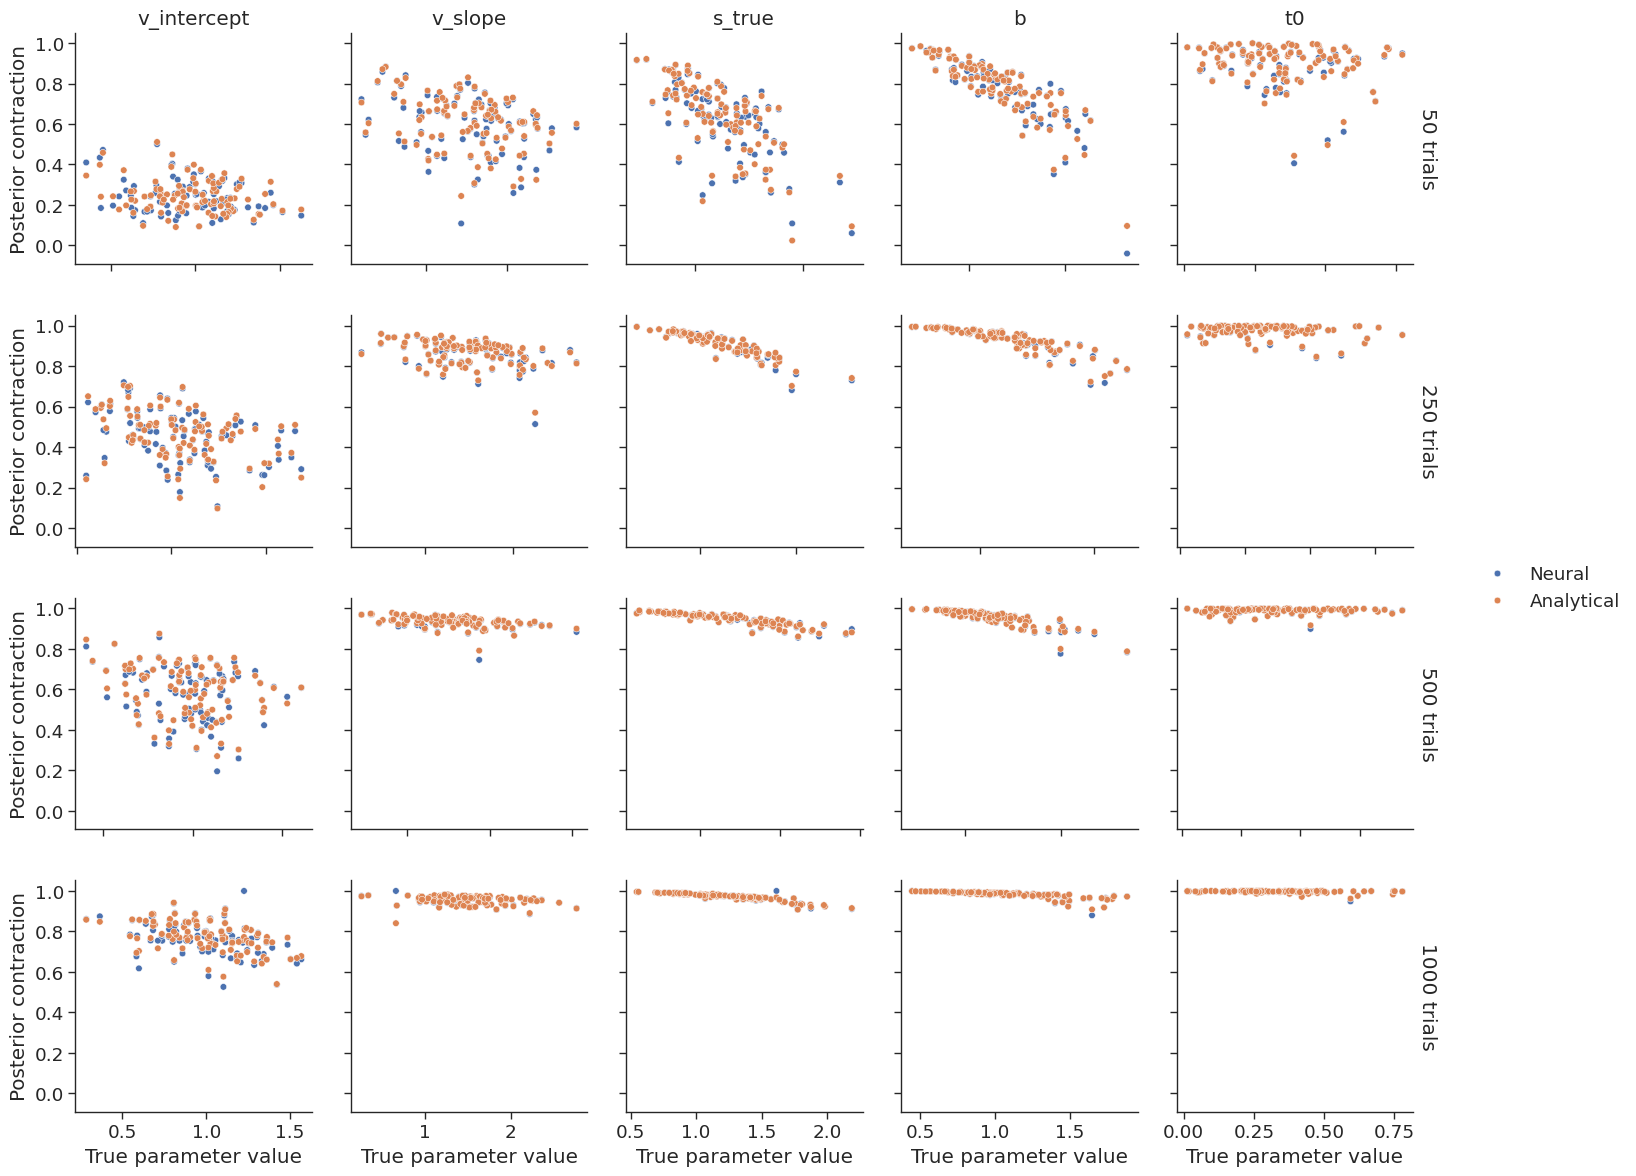

In [132]:
g = sns.FacetGrid(
    df_posterior_contraction_rdm_join,
    row="num_obs",
    col="param",
    col_order=dt_merged_rdm_approx.param_names,
    sharex=False,
    sharey=True,
    margin_titles=True,
)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.scatterplot, x="true", y="value", hue="method")

g.set_xlabels(label="True parameter value")
g.set_ylabels(label="Posterior contraction")

g.set_titles(col_template="{col_name}", row_template="{row_name} trials")

g.add_legend({
    "Neural": g._legend_data["contraction_approx"],
    "Analytical": g._legend_data["contraction_ref"],
})

# plt.legend()

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val != 1000:
        ax.set_xticklabels([])

g.savefig("parameter_recovery/posterior_contraction_single_rdm.png")

In [133]:
def calc_coverage_df(dt):
    lower = dt.quantile(dim=["chain", "draw"], q=0.025)
    upper = dt.quantile(dim=["chain", "draw"], q=0.975)
    true = dt.true
    return (((true > lower) & (true < upper))
        .theta
        .mean(dim="subject")
        .to_dataset(name="coverage")
        .to_dataframe()
        .reset_index()
    )

df_coverage_rdm_approx = calc_coverage_df(posterior_stacked_rdm_approx)
df_coverage_rdm_ref = calc_coverage_df(posterior_stacked_rdm_ref)

df_coverage_rdm_join = df_coverage_rdm_approx.merge(
    df_coverage_rdm_ref, on=["num_obs", "param"], suffixes=["_approx", "_ref"],
).melt(
    id_vars=["num_obs", "param"],
    value_vars=["coverage_approx", "coverage_ref"],
    var_name="method",
)

/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/seaborn/axisgrid.

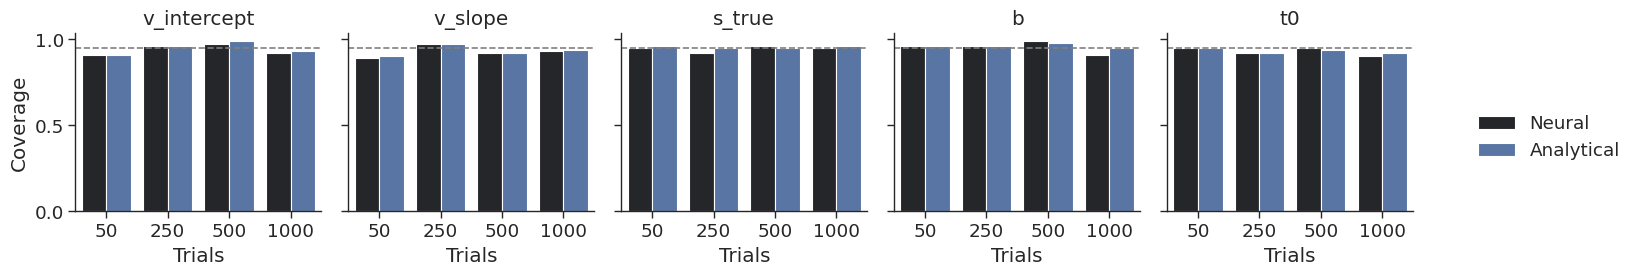

In [134]:
g = sns.FacetGrid(
    df_coverage_rdm_join,
    col="param",
    col_order=dt_merged_rdm_approx.param_names,
    sharex=False,
    sharey=True,
    margin_titles=True,
)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.barplot, x="num_obs", y="value", hue="method")

g.refline(y=0.95)

g.set_xlabels(label="Trials")
g.set_ylabels(label="Coverage")

g.set_titles(col_template="{col_name}")

g.add_legend({
    "Neural": g._legend_data["coverage_approx"],
    "Analytical": g._legend_data["coverage_ref"],
})

g.savefig("parameter_recovery/coverage_single_rdm.png")

## CRDM

In [135]:
dt_dict_crdm_approx = {}

for t in NUM_OBS:
    dt_path = f"../multirun/crdm/crdm/model.num_bins=12/model.num_mid=128/model.recovery_prior.v_c_slope_loc=2.5/model.sampler.dt=0.0005/optimizer=adam_cosine_decay/test_num_obs={t}/train_steps=1000000/parameter_recovery_approx.nc"
    dt_dict_crdm_approx[t] = open_datatree(dt_path)

In [136]:
dt_merged_crdm_approx = merge_datatrees(dt_dict_crdm_approx)

In [137]:
posterior_stacked_crdm_approx = stack_posterior(dt_merged_crdm_approx)

In [138]:
df_posterior_median_crdm_approx = calc_posterior_median_df(posterior_stacked_crdm_approx)


In [139]:
df_cor_crdm_approx = calc_posterior_median_true_correlation(df_posterior_median_crdm_approx)
df_cor_crdm_approx

,num_obs,param,level_2,true
0,50,amp,theta,0.509451
1,50,b,theta,0.912279
2,50,s_true,theta,0.860605
3,50,t0,theta,0.992937
4,50,tau,theta,0.688428
5,50,v_c_intercept,theta,0.329366
6,50,v_c_slope,theta,0.640677
7,250,amp,theta,0.716060
8,250,b,theta,0.974245
9,250,s_true,theta,0.970838


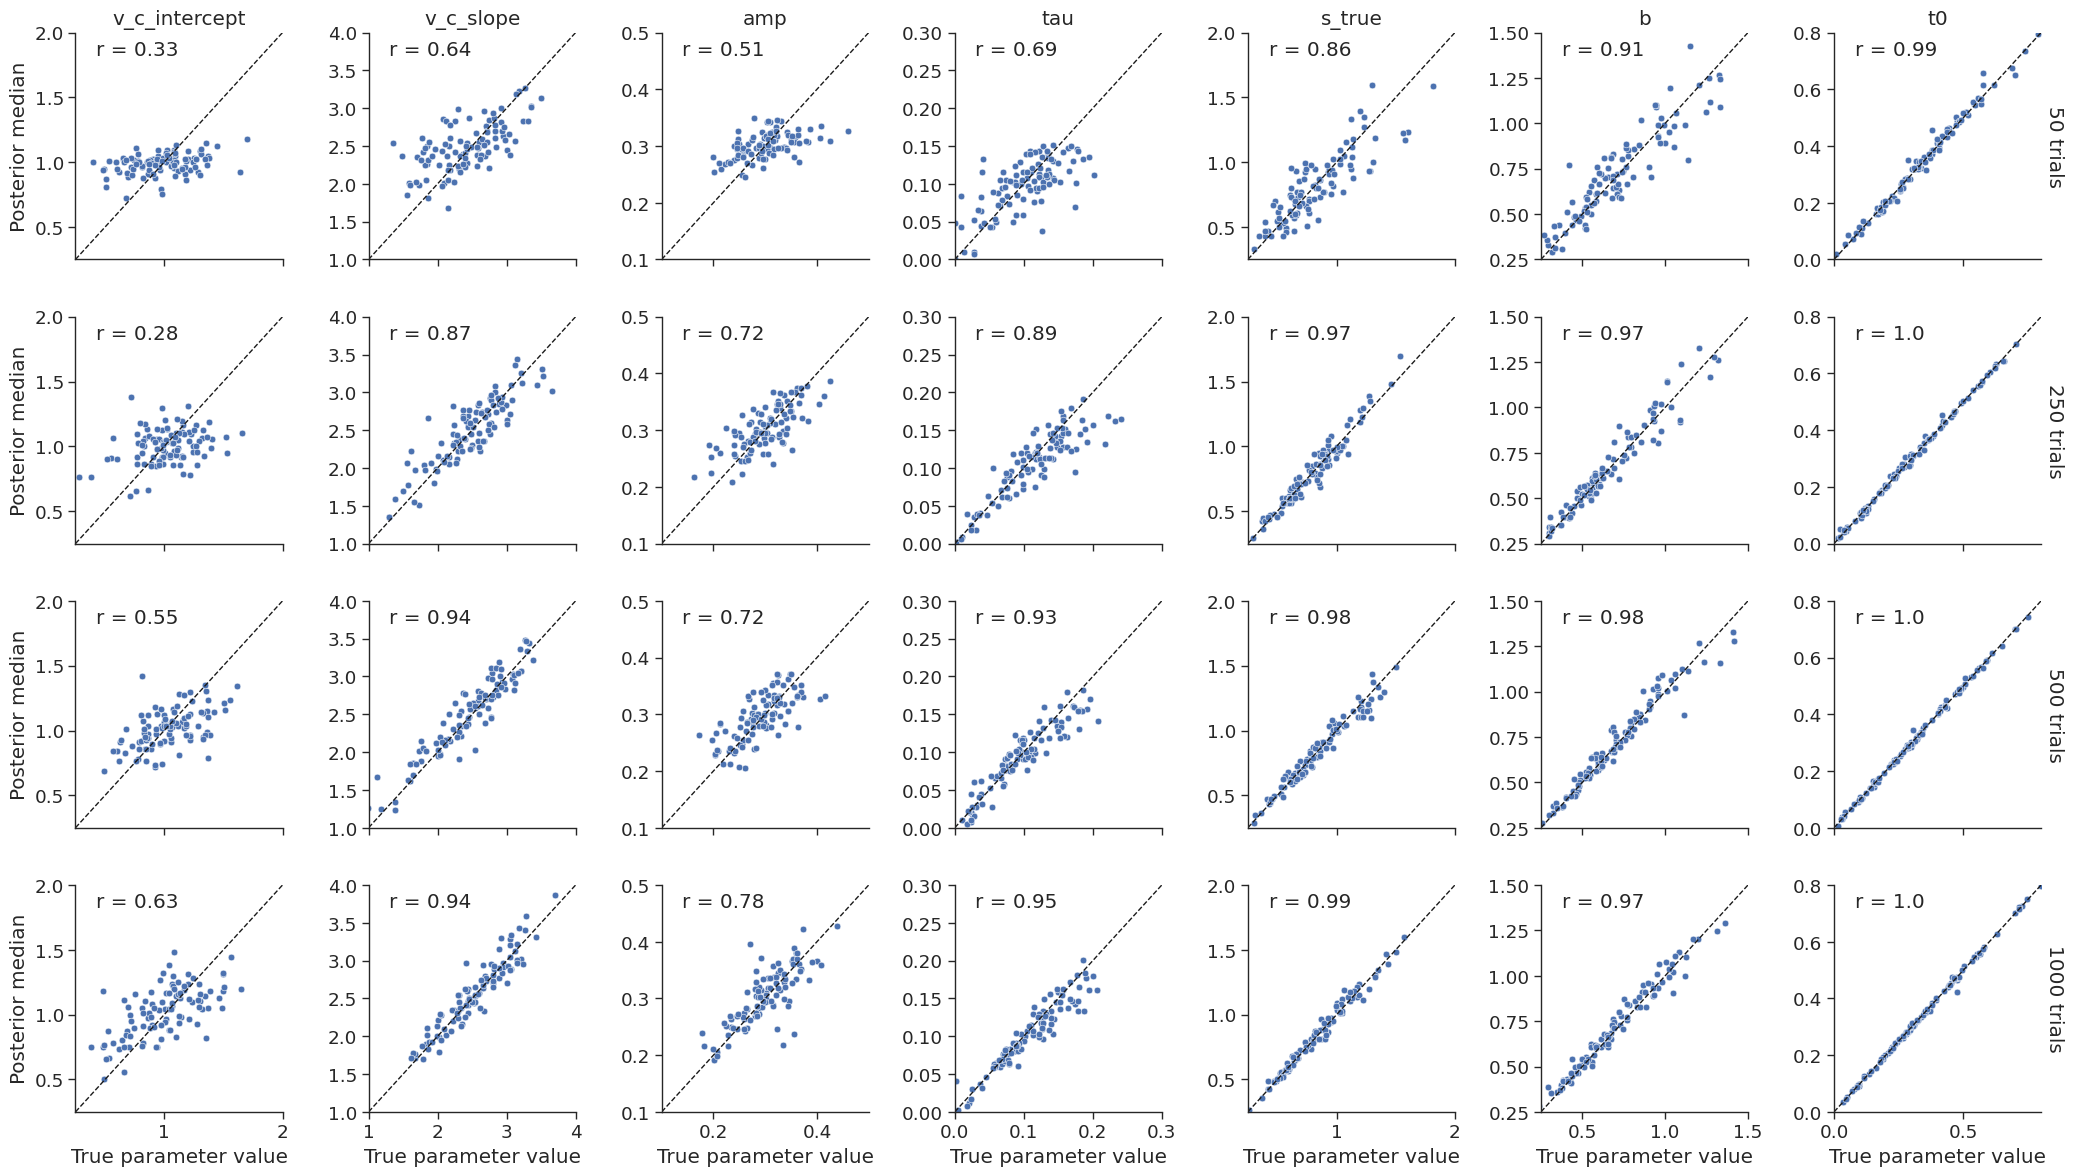

In [140]:
sns.set_theme(context="paper", style="ticks", font_scale=1.5)

g = sns.FacetGrid(df_posterior_median_crdm_approx, row="num_obs", col="param", sharex=False, sharey=False, margin_titles=True)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.scatterplot, x="true", y="theta")

g.set_xlabels(label="True parameter value")
g.set_ylabels(label="Posterior median")

g.set_titles(col_template="{col_name}", row_template="{row_name} trials")

lims_dict = {
    "v_c_intercept": (0.25, 2.0),
    "v_c_slope": (1.0, 4.0),
    "amp": (0.1, 0.5),
    "tau": (0, 0.3),
    "s_true": (0.25, 2.0),
    "b": (0.25, 1.5),
    "t0": (0, 0.8),
}

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val != 1000:
        ax.set_xticklabels([])

    ax.set_xlim(lims_dict[col_val])
    ax.set_ylim(lims_dict[col_val])
    ax.plot(lims_dict[col_val], lims_dict[col_val], 'k--', lw=1)
    cor = np.round(df_cor_crdm_approx[(df_cor_crdm_approx["num_obs"] == row_val) & (df_cor_crdm_approx["param"] == col_val)]["true"].item(), 2)
    ax.text(0.1, 0.9, f"r = {cor}", transform=ax.transAxes)

g.savefig("parameter_recovery/parameter_recovery_single_crdm.png")

In [141]:
posterior_prior_stacked_crdm_approx = merge_prior(posterior_stacked_crdm_approx, dt_merged_crdm_approx)

In [142]:
df_posterior_contraction_crdm_approx = calc_posterior_contraction_df(posterior_prior_stacked_crdm_approx)
df_posterior_contraction_crdm_approx["contraction"] = np.clip(df_posterior_contraction_crdm_approx["contraction"], 0, 1)

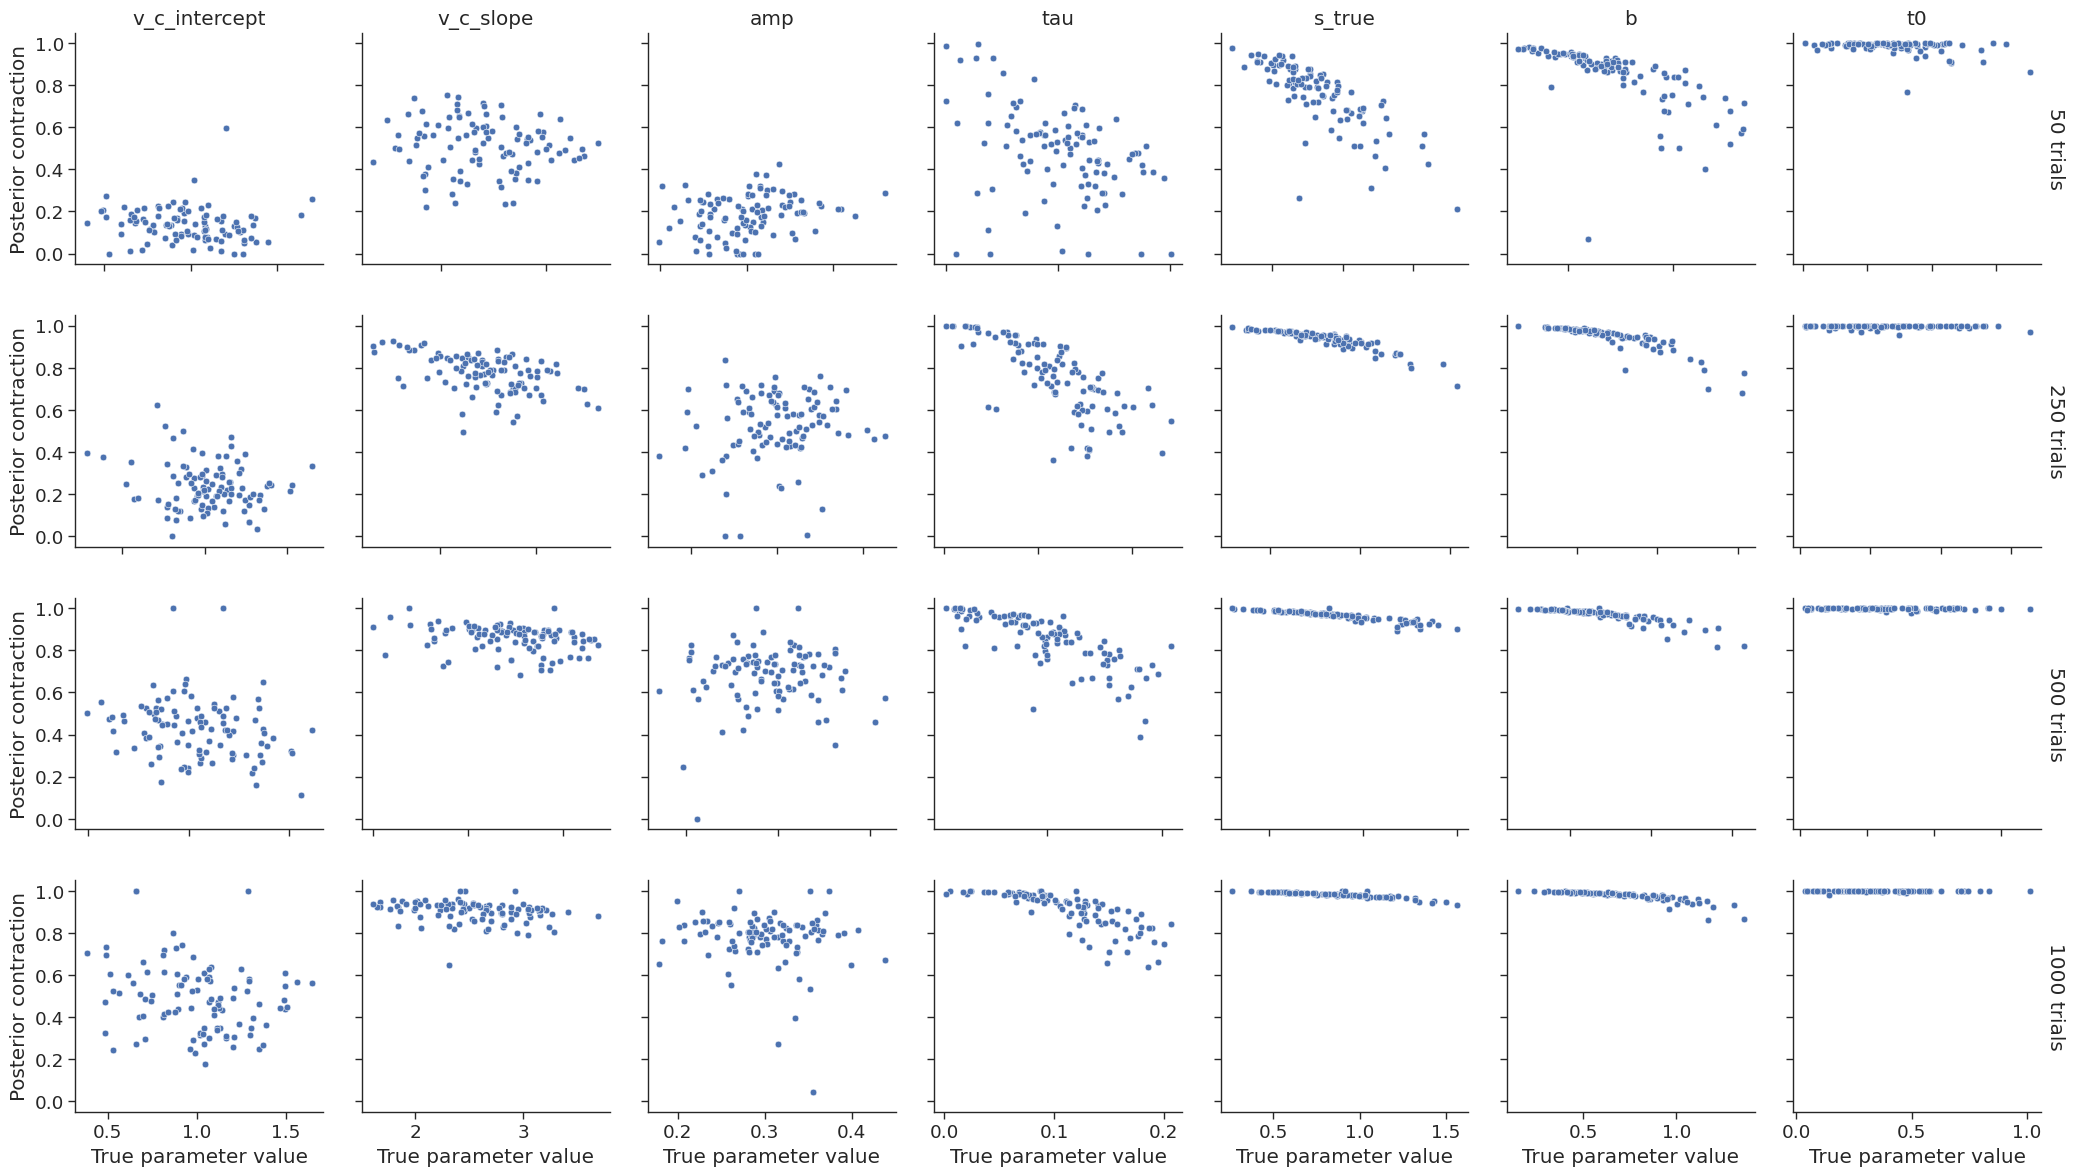

In [143]:
g = sns.FacetGrid(
    df_posterior_contraction_crdm_approx,
    row="num_obs",
    col="param",
    col_order=dt_merged_crdm_approx.param_names,
    sharex=False,
    sharey=True,
    margin_titles=True,
)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.scatterplot, x="true", y="contraction")

g.set_xlabels(label="True parameter value")
g.set_ylabels(label="Posterior contraction")

g.set_titles(col_template="{col_name}", row_template="{row_name} trials")

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val != 1000:
        ax.set_xticklabels([])

g.savefig("parameter_recovery/posterior_contraction_single_crdm.png")

In [144]:
df_coverage_crdm_approx = calc_coverage_df(posterior_stacked_crdm_approx)

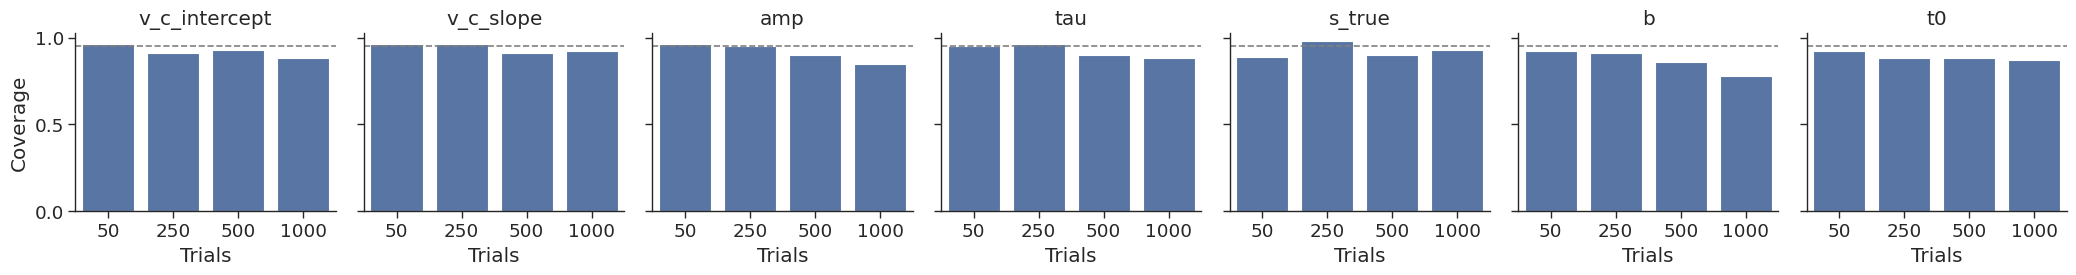

In [145]:
g = sns.FacetGrid(
    df_coverage_crdm_approx,
    col="param",
    col_order=dt_merged_crdm_approx.param_names,
    sharex=False,
    sharey=True,
    margin_titles=True,
)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.barplot, x="num_obs", y="coverage")

g.refline(y=0.95)

g.set_xlabels(label="Trials")
g.set_ylabels(label="Coverage")

g.set_titles(col_template="{col_name}")

g.savefig("parameter_recovery/coverage_single_crdm.png")